## BMF coherence length vs `delta_n` for all supported `d` coefficients

BaMgF4 (BMF) の各 `d` 係数について、`theta = 0 deg` の理論コヒーレンス長

$$L_c = \frac{\lambda}{4 |n_\omega - n_{2\omega}|}$$

を計算します。ここでは SH 側の屈折率補正 `delta_n` を `-0.001` から `+0.001` まで掃引し、`L_c` がどれくらい変化するかを可視化します。

In [24]:
import copy
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "stixsans"
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [25]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "test_codes":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from shg_analysis import SHGDataAnalysis
from fitting_strategies.braun1997 import Braun1997Strategy

### Calculation settings

`delta_n` は既存 fitting code と同じく、各 `d` 係数の位相不整合に効く SH 側の主軸屈折率へ加えます。`Lc` は notebook 全体で `lambda / (4 * |n_w - n_2w|)` に統一します。`Lc` は実験 config に依存しない量として、`d33` も 1 本で扱います。

In [26]:
mock_data = pd.DataFrame({"position": [0.0]})

meta_base = {
    "sample": "BMF_delta_n_theory",
    "material": "BaMgF4",
    "method": "rotation",
    "wavelength_nm": 1064.0,
    "ref_ch": 1,
    "sig_ch": 2,
    "repetition": "1000Hz",
    "operator": "user",
    "notes": "",
    "start": 0.0,
    "end": 0.0,
    "step": 1.0,
    "timestamp": "2026-07-16T00:00:00.000000",
    "thickness_info": {"t_center_mm": 1.0},
    "beam_r_x": 50.0,
    "beam_r_y": 50.0,
    "use_raytrace": False,
}

meta_configs = {
    "d31": {
        "d_component": "d_31",
        "crystal_orientation": "010",
        "rot/trans_axis": "100",
        "input_polarization": 0.0,
        "detected_polarization": 90.0,
    },
    "d32": {
        "d_component": "d_32",
        "crystal_orientation": "100",
        "rot/trans_axis": "010",
        "input_polarization": 0.0,
        "detected_polarization": 90.0,
    },
    "d33": {
        "d_component": "d_33",
        "crystal_orientation": "010",
        "rot/trans_axis": "001",
        "input_polarization": 0.0,
        "detected_polarization": 0.0,
    },
    "d15": {
        "d_component": "d_15",
        "crystal_orientation": "010",
        "rot/trans_axis": "100",
        "input_polarization": 45.0,
        "detected_polarization": 0.0,
    },
    "d24": {
        "d_component": "d_24",
        "crystal_orientation": "100",
        "rot/trans_axis": "010",
        "input_polarization": 45.0,
        "detected_polarization": 0.0,
    },
}

meta_dict = {}
for label, config in meta_configs.items():
    meta = copy.deepcopy(meta_base)
    meta.update(config)
    meta_dict[label] = meta

config_df = pd.DataFrame(meta_configs).T[
    ["d_component", "crystal_orientation", "rot/trans_axis", "input_polarization", "detected_polarization"]
]
config_df

,d_component,crystal_orientation,rot/trans_axis,input_polarization,detected_polarization
d31,d_31,010,100,0.0,90.0
d32,d_32,100,010,0.0,90.0
d33,d_33,010,001,0.0,0.0
d15,d_15,010,100,45.0,0.0
d24,d_24,100,010,45.0,0.0


In [27]:
def build_strategy(meta):
    analysis = SHGDataAnalysis(mock_input={"meta": meta, "data": mock_data})
    return Braun1997Strategy(analysis)


strategies = {label: build_strategy(meta) for label, meta in meta_dict.items()}


def coherence_length_mm(strategy, meta, delta_n):
    wavelength_mm = float(meta["wavelength_nm"]) * 1e-6
    dn_override = strategy._delta_n_override(meta, float(delta_n))
    n_w = strategy._theory_n_at_zero(
        meta["input_polarization"],
        meta["wavelength_nm"],
        meta=meta,
        dn_override=dn_override,
    )
    n_2w = strategy._theory_n_at_zero(
        meta["detected_polarization"],
        meta["wavelength_nm"] / 2.0,
        meta=meta,
        dn_override=dn_override,
    )
    delta_n_eff = abs(float(n_w) - float(n_2w))
    if not np.isfinite(delta_n_eff) or np.isclose(delta_n_eff, 0.0):
        return np.nan
    return float(wavelength_mm / (4.0 * delta_n_eff))


delta_n_array = np.linspace(-0.001, 0.001, 401)

results_df = pd.DataFrame({"delta_n": delta_n_array})
for label, strategy in strategies.items():
    meta = meta_dict[label]
    results_df[f"Lc_{label}_um"] = [
        coherence_length_mm(strategy, meta, dn) * 1000.0
        for dn in delta_n_array
    ]

results_df.head()

,delta_n,Lc_d31_um,Lc_d32_um,Lc_d33_um,Lc_d15_um,Lc_d24_um
0,-0.001000,949.946935,11.418188,41.122125,26.685970,107.615809
1,-0.000995,967.217715,11.415738,41.090363,26.672591,107.833942
2,-0.000990,985.128116,11.413289,41.058651,26.659225,108.052960
3,-0.000985,1003.714342,11.410841,41.026987,26.645872,108.272870
4,-0.000980,1023.015380,11.408394,40.995372,26.632533,108.493677


### Summary at `delta_n = -0.001, 0, +0.001`

In [28]:
summary_rows = []
for label, strategy in strategies.items():
    meta = meta_dict[label]
    lc_minus = coherence_length_mm(strategy, meta, -0.001) * 1000.0
    lc_zero = coherence_length_mm(strategy, meta, 0.0) * 1000.0
    lc_plus = coherence_length_mm(strategy, meta, 0.001) * 1000.0
    summary_rows.append({
        "label": label,
        "d_component": meta["d_component"],
        "Lc_delta_n_-0.001_um": lc_minus,
        "Lc_delta_n_0_um": lc_zero,
        "Lc_delta_n_+0.001_um": lc_plus,
        "change_range_um": lc_plus - lc_minus,
        "change_range_pct_of_delta_n_0": 100.0 * (lc_plus - lc_minus) / lc_zero,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,label,d_component,Lc_delta_n_-0.001_um,Lc_delta_n_0_um,Lc_delta_n_+0.001_um,change_range_um,change_range_pct_of_delta_n_0
0,d31,d_31,949.946935,369.452470,154.652569,-795.294365,-215.262971
1,d32,d_32,11.418188,10.948230,10.515428,-0.902760,-8.245720
2,d33,d_33,41.122125,35.616077,31.410383,-9.711742,-27.267860
3,d15,d_15,26.685970,24.252847,22.226336,-4.459634,-18.388085
4,d24,d_24,107.615809,180.736506,563.851054,456.235245,252.431152


### Overlay plot

全 d 係数を同じ軸で比較します。

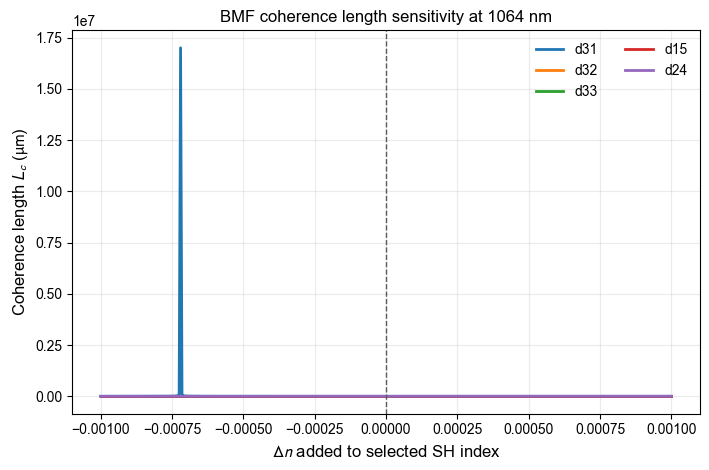

In [29]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))

for label in meta_dict:
    ax.plot(results_df["delta_n"], results_df[f"Lc_{label}_um"], linewidth=2.0, label=label)

ax.axvline(0.0, color="0.35", linestyle="--", linewidth=1.0)
ax.set_xlabel(r"$\Delta n$ added to selected SH index")
ax.set_ylabel(r"Coherence length $L_c$ ($\mathrm{\mu m}$)")
ax.set_title("BMF coherence length sensitivity at 1064 nm")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()

### Per-coefficient plots

`delta_n = 0` の値からの相対変化も合わせて見ます。

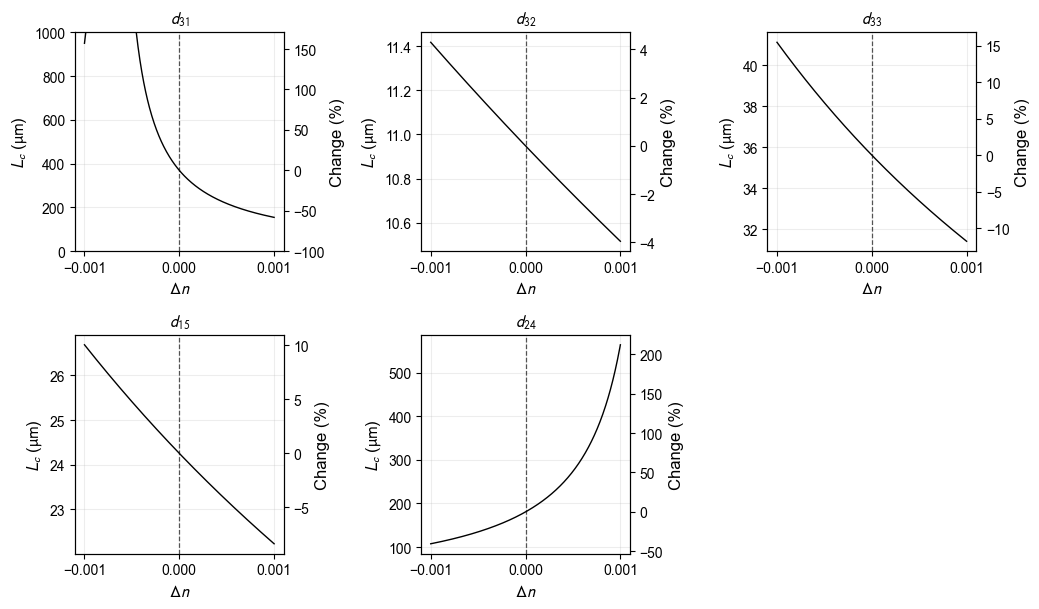

In [35]:
display_labels = {
    "d31": r"$d_{\mathrm{31}}$",
    "d32": r"$d_{\mathrm{32}}$",
    "d33": r"$d_{\mathrm{33}}$",
    "d15": r"$d_{\mathrm{15}}$",
    "d24": r"$d_{\mathrm{24}}$",
}


def add_lc_plot_with_relative_axis(ax, label):
    y = results_df[f"Lc_{label}_um"].to_numpy(dtype=float)
    y0 = float(summary_df.loc[summary_df["label"] == label, "Lc_delta_n_0_um"].iloc[0])

    ax.plot(results_df["delta_n"], y, color="black", linewidth=1.0)
    ax.axvline(0.0, color="black", linestyle="--", linewidth=0.9, alpha=0.65)
    ax.set_title(display_labels[label])
    ax.grid(True, alpha=0.22)
    ax.set_xlabel(r"$\Delta n$")
    ax.set_xticks([-0.001, 0, 0.001])
    ax.set_ylabel(r"$L_c$ ($\mathrm{\mu m}$)", color="black")
    ax.tick_params(axis="both", colors="black")

    if label == "d31":
        ax.set_ylim(top=1000, bottom=0)

    y_min, y_max = ax.get_ylim()
    ax2 = ax.twinx()
    ax2.set_ylim(100.0 * (y_min / y0 - 1.0), 100.0 * (y_max / y0 - 1.0))
    ax2.set_ylabel("Change (%)", color="black")
    ax2.tick_params(axis="y", colors="black")
    return ax, ax2


fig, axs = plt.subplots(2, 3, figsize=(10.5, 6.2), sharex=False)
axs = axs.ravel()

for ax, label in zip(axs, meta_dict):
    add_lc_plot_with_relative_axis(ax, label)

for ax in axs[len(meta_dict):]:
    ax.axis("off")

for ax in axs[:]:
    ax.set_xlabel(r"$\Delta n$")

fig.tight_layout()
plt.show()

### Individual per-coefficient plots

5 つの `d` 係数を、それぞれ独立した figure として出力します。

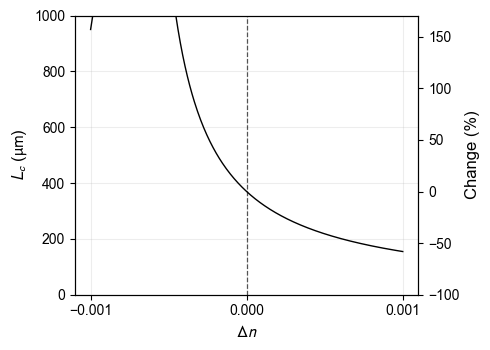

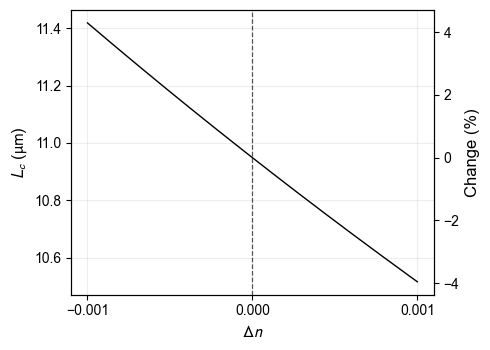

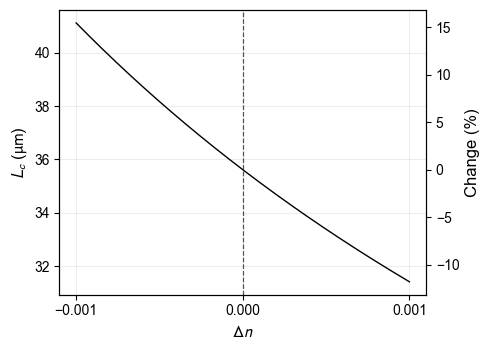

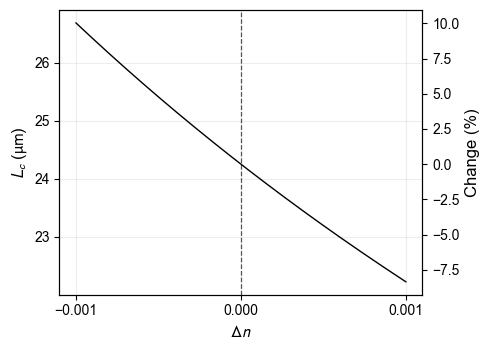

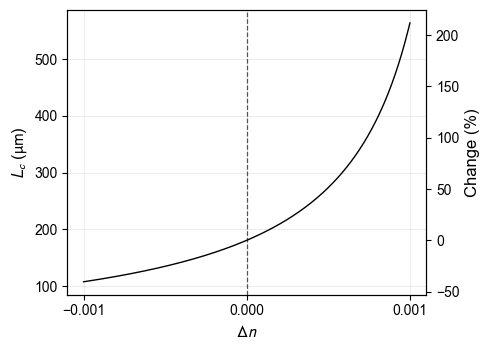

In [34]:
for label in meta_dict:
    fig, ax = plt.subplots(figsize=(5.0, 3.6))
    add_lc_plot_with_relative_axis(ax, label)
    ax.set_xlabel(r"$\Delta n$")
    fig.tight_layout()
    plt.show()


### Save results if needed

必要ならコメントアウトを外して CSV と PNG を保存します。

In [32]:
# output_dir = PROJECT_ROOT / "results" / "BMF_coherence_length_delta_n"
# output_dir.mkdir(parents=True, exist_ok=True)
# results_df.to_csv(output_dir / "BMF_Lc_vs_delta_n_all_d.csv", index=False)
# summary_df.to_csv(output_dir / "BMF_Lc_delta_n_summary_all_d.csv", index=False)